In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT
from data_split import create_train_val_split
from extract_egemaps_feature import extract_egemaps_features_from_csv
from visualization import plot_training_curves, plot_dataset_comparison
from dataset import create_dataloaders
from train import train
import numpy as np

/opt/anaconda3/envs/madress-2023-x86/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration Parameters


In [2]:
DATASET_NAME = "ADReSS"

In [3]:
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemaps-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-egemaps-val.csv"
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{DATASET_NAME}"
FEATURE_DIR_NAME = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_egemaps_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / "models" / f"{DATASET_NAME}_egemaps_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using mps


## Step 1: Create Train/Val Split

In [5]:
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir=RAW_AUDIO_DIR,
    train_csv_path=TRAIN_CSV,
    val_csv_path=VAL_CSV,
    feature_dir_name=FEATURE_DIR_NAME,
    dataset_name=DATASET_NAME,
    xlsr=False
)

============= ADReSS Train(80.0%) and Val(20%) Split Complete! =============
Training set: 124 samples (Control: 62, Dementia: 62)
Validation set: 32 samples (Control: 16, Dementia: 16)


## Step 2: Extract eGeMAPS Features

In [6]:
extract_egemaps_features_from_csv(TRAIN_CSV, raw_audio_dir=RAW_AUDIO_DIR)

extract_egemaps_features_from_csv(VAL_CSV, raw_audio_dir=RAW_AUDIO_DIR)


============= Extraction eGeMaps features =============
124 Audio Files


Extracting: 100%|██████████| 124/124 [00:00<00:00, 46267.56it/s]

Successfully extracted: 0
Already Exists (Skipped): 124
Total: 124
Errors: 0



============= Extraction eGeMaps features =============
32 Audio Files


Extracting: 100%|██████████| 32/32 [00:00<00:00, 29247.71it/s]

Successfully extracted: 0
Already Exists (Skipped): 32
Total: 32
Errors: 0


## Step 3: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=False)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=False)

Loading completed: 124 samples
Control: 62, Dementia: 62


Loading completed: 32 samples
Control: 16, Dementia: 16




## Step 4: Train Model with Multiple Seeds

In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21

Seed 21:
Val Acc=71.88%, F1=0.6667, Val Loss=0.6860
Control Acc=87.50%, Dementia Acc=56.25%


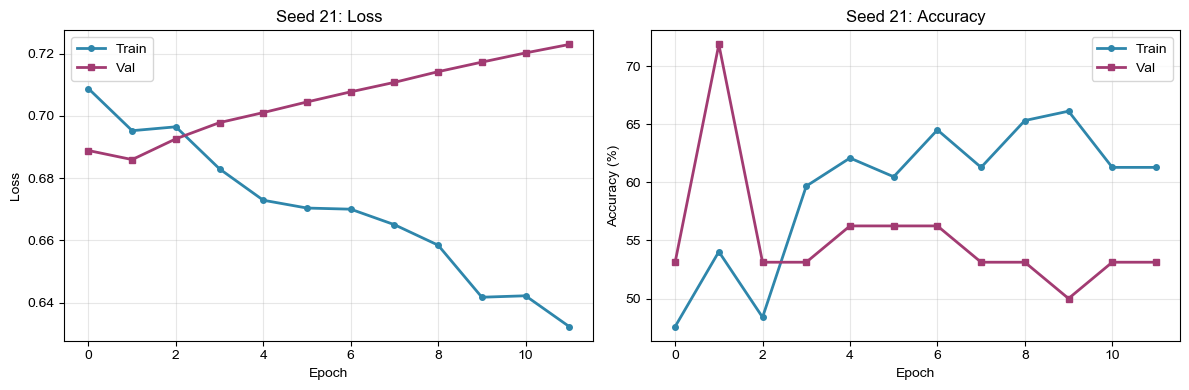

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=False)
all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42:
Val Acc=59.38%, F1=0.4800, Val Loss=0.6931
Control Acc=81.25%, Dementia Acc=37.50%


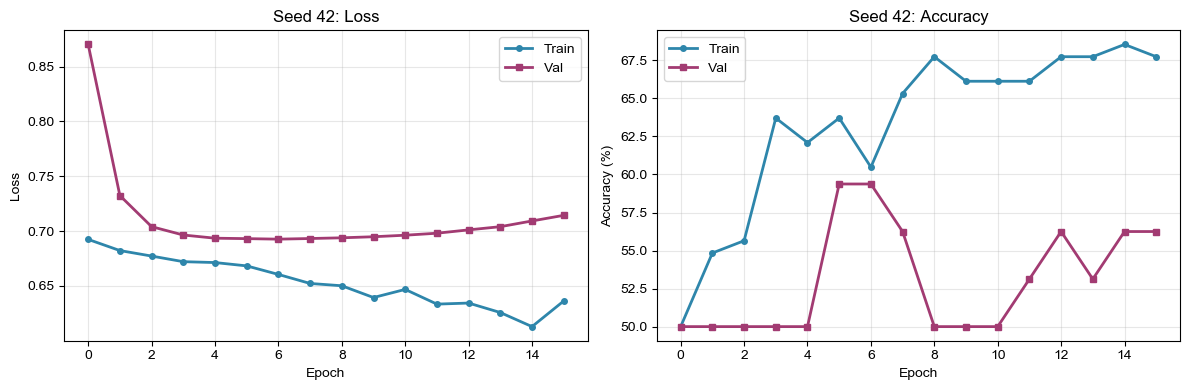

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=False)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84:
Val Acc=56.25%, F1=0.4615, Val Loss=0.6915
Control Acc=75.00%, Dementia Acc=37.50%


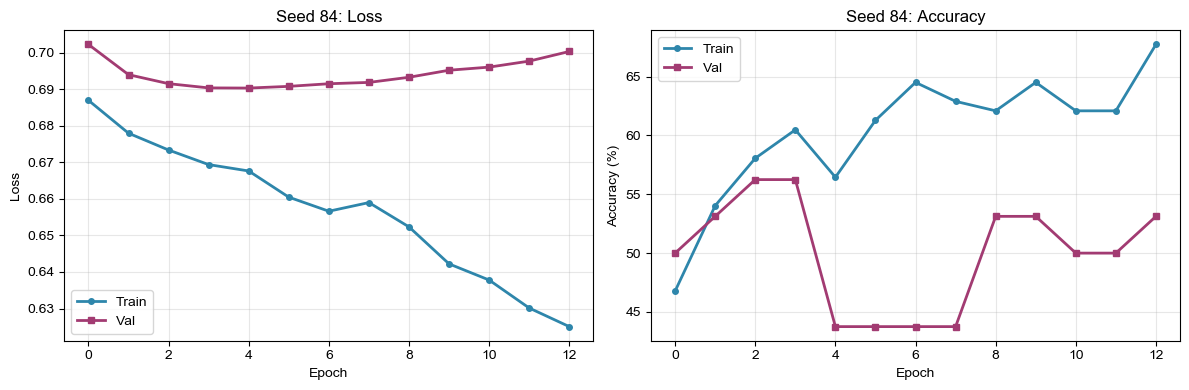

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=False)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168:
Val Acc=50.00%, F1=0.6667, Val Loss=0.9503
Control Acc=0.00%, Dementia Acc=100.00%


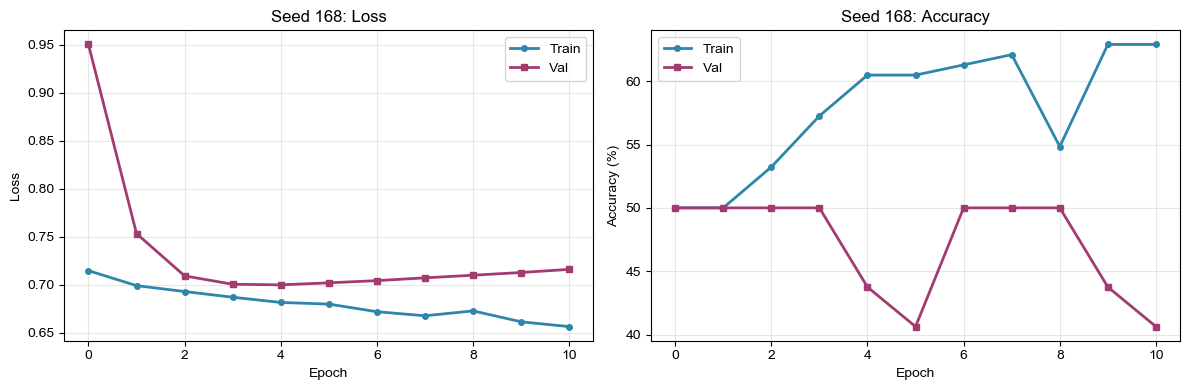

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=False)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336:
Val Acc=56.25%, F1=0.5000, Val Loss=0.6990
Control Acc=68.75%, Dementia Acc=43.75%


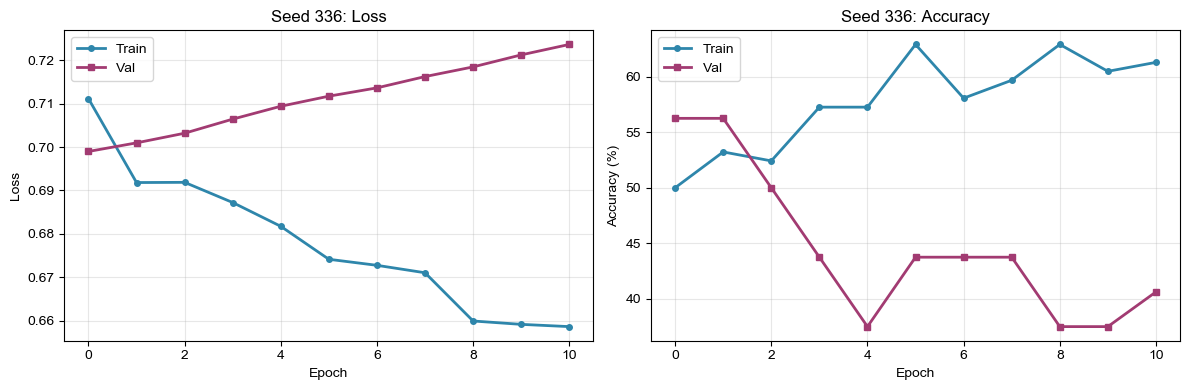

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=False)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 5: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.2f}%")


Mean Validation Accuracy: 58.75% ± 8.09%
Mean Validation Loss: 0.7440 ± 0.1154
Mean Control Accuracy: 62.50% ± 35.63%
Mean Dementia Accuracy: 55.00% ± 26.29%
Mean F1 Score: 0.5550 ± 0.1029

Detailed Results:
Seed 21: Acc=71.88%, Loss=0.6860, Control Acc=87.50%, Dementia Acc=56.25%, F1=0.67%
Seed 42: Acc=59.38%, Loss=0.6931, Control Acc=81.25%, Dementia Acc=37.50%, F1=0.48%
Seed 84: Acc=56.25%, Loss=0.6915, Control Acc=75.00%, Dementia Acc=37.50%, F1=0.46%
Seed 168: Acc=50.00%, Loss=0.9503, Control Acc=0.00%, Dementia Acc=100.00%, F1=0.67%
Seed 336: Acc=56.25%, Loss=0.6990, Control Acc=68.75%, Dementia Acc=43.75%, F1=0.50%


## Step 6: Test Best Model on Lu Dataset


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
# Find all indices with max accuracy
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
else:
    best_idx = max_acc_indices[0]

BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]

print(f"\nBest Model: Seed {BEST_SEED}")
print(f"Validation Accuracy: {BEST_VAL_ACC:.2f}%")
print(f"Validation Loss: {BEST_VAL_LOSS:.4f}")
print(f"F1 Score: {BEST_F1:.4f}")

BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"
print(f"Model Path: {BEST_MODEL_PATH}")



Best Model: Seed 21
Validation Accuracy: 71.88%
Validation Loss: 0.6860
F1 Score: 0.6667
Model Path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS_egemaps_multi_seed/seed_21/best.pth


In [16]:
TEST_DATASET = "Lu"
LU_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{TEST_DATASET}"
LU_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{TEST_DATASET}_egemaps_features"
LU_CSV_PATH = PROJECT_ROOT / f"data/processed/{TEST_DATASET}-egemaps-test.csv"

# Create features directory
LU_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Collect audio files from Lu dataset
import pandas as pd
test_samples = []

for label_dir in ["Control", "Dementia"]:
    label_audio_dir = LU_AUDIO_DIR / label_dir
    if not label_audio_dir.exists():
        print(f"Error: Directory does not exist: {label_audio_dir}")
        continue
    
    label = 0 if label_dir == "Control" else 1
    
    audio_files = list(label_audio_dir.glob("*.wav")) + list(label_audio_dir.glob("*.mp3"))
    for audio_file in sorted(audio_files):
        session_id = audio_file.stem
        feature_path = f"{LU_FEATURES_DIR}/{session_id}.egemaps.pt"
        
        test_samples.append({
            "session_id": session_id,
            "egemaps_path": feature_path,
            "ad": label,
            "audio_path": str(audio_file.relative_to(PROJECT_ROOT))
        })

# Create CSV
test_df = pd.DataFrame(test_samples)
LU_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
test_df.to_csv(LU_CSV_PATH, index=False)


In [17]:
extract_egemaps_features_from_csv(
    csv_path=LU_CSV_PATH,
    raw_audio_dir=LU_AUDIO_DIR
)


============= Extraction eGeMaps features =============
53 Audio Files


Extracting: 100%|██████████| 53/53 [00:00<00:00, 29412.29it/s]

Successfully extracted: 0
Already Exists (Skipped): 53
Total: 53
Errors: 0


In [18]:
# Load the best model
from model import AD_EGE_Model

print(f"Loading best model from: {BEST_MODEL_PATH}")

# Create model with eGeMAPS configuration
from config import EGEMAPS_DROPOUT

test_model = AD_EGE_Model(dropout=EGEMAPS_DROPOUT)

# Load checkpoint
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu', weights_only=False)

if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# Handle potential 'model.' prefix in state dict keys
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('model.'):
        new_key = key[6:]
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

test_model.load_state_dict(new_state_dict)
test_model = test_model.to(device)
test_model.eval()

print(f"Model loaded successfully")


Loading best model from: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/Adaptation_is_all_you_need/ad_detection/models/ADReSS_egemaps_multi_seed/seed_21/best.pth
Model loaded successfully


In [19]:
# Test on Lu dataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# Create test data loader
lu_test_loader = create_dataloaders(
    data_csv=LU_CSV_PATH,
    batch_size=32,
    num_workers=0,
    xlsr=False
)

# Perform predictions
all_preds = []
all_labels = []
all_probs = []

test_model.eval()
with torch.no_grad():
    for features, labels in tqdm(lu_test_loader, desc=f"Testing on {TEST_DATASET}"):
        features = features.to(device)
        labels = labels.to(device)
        
        # eGeMAPS model doesn't need mask parameter
        logits = test_model(features)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
lu_accuracy = accuracy_score(all_labels, all_preds)

# Calculate accuracy for each class
control_mask = all_labels == 0
dementia_mask = all_labels == 1

control_acc = accuracy_score(all_labels[control_mask], all_preds[control_mask])
dementia_acc = accuracy_score(all_labels[dementia_mask], all_preds[dementia_mask])


Loading completed: 53 samples
Control: 25, Dementia: 28




Testing on Lu: 100%|██████████| 2/2 [00:00<00:00, 88.58it/s]


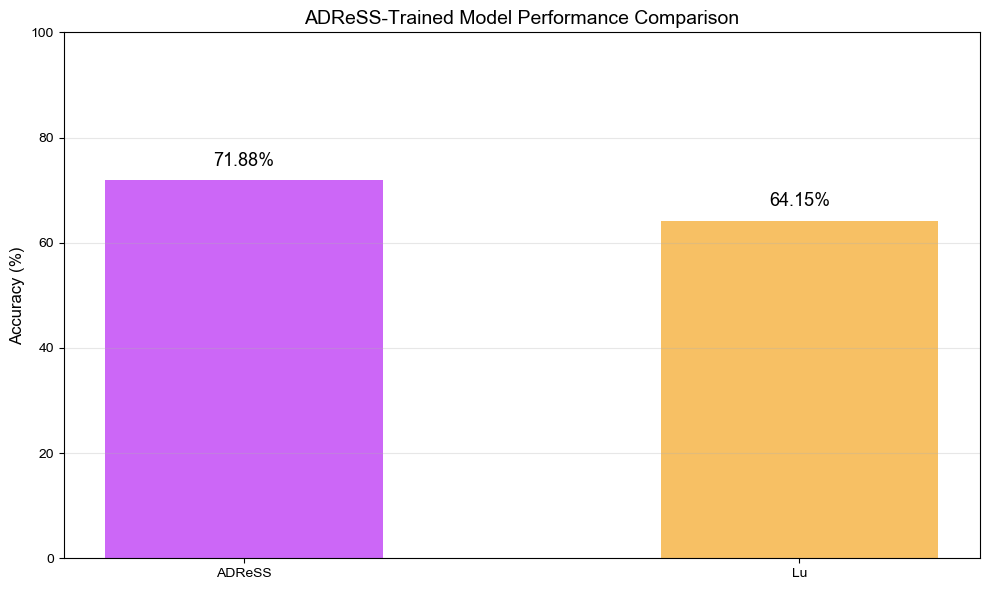

ADReSS Dataset (Validation):
Overall Accuracy: 71.88%, F1 Score: 0.6667
Control Accuracy: 87.50%, Dementia Accuracy: 56.25%

Lu Dataset (Test):
Overall Accuracy: 64.15%, F1 Score: 0.5957
Control Accuracy: 80.00%, Dementia Accuracy: 50.00%

Performance Drop: 7.72%


In [20]:
# Performance Comparison Visualization
from sklearn.metrics import f1_score

# Prepare data for visualization
dataset_names = [DATASET_NAME, TEST_DATASET]
accuracies = [BEST_VAL_ACC, lu_accuracy * 100]

# Plot comparison using the new visualization function
plot_dataset_comparison(
    dataset_names=dataset_names,
    accuracies=accuracies,
    title=f'{DATASET_NAME}-Trained Model Performance Comparison'
)

# Calculate F1 score for Lu dataset
lu_f1 = f1_score(all_labels, all_preds, pos_label=1)

# Get best model metrics
BEST_CONTROL_ACC = all_results['control_accs'][best_idx] * 100
BEST_DEMENTIA_ACC = all_results['dementia_accs'][best_idx] * 100

# Print summary
print(f"{DATASET_NAME} Dataset (Validation):")
print(f"Overall Accuracy: {BEST_VAL_ACC:.2f}%, F1 Score: {BEST_F1:.4f}")
print(f"Control Accuracy: {BEST_CONTROL_ACC:.2f}%, Dementia Accuracy: {BEST_DEMENTIA_ACC:.2f}%")

print(f"\n{TEST_DATASET} Dataset (Test):")
print(f"Overall Accuracy: {lu_accuracy*100:.2f}%, F1 Score: {lu_f1:.4f}")
print(f"Control Accuracy: {control_acc*100:.2f}%, Dementia Accuracy: {dementia_acc*100:.2f}%")

print(f"\nPerformance Drop: {BEST_VAL_ACC - lu_accuracy*100:.2f}%")
